# 02 — Análise Exploratória e Geração de Insights

Perguntas respondidas:
1. Como o volume de pedidos evoluiu ao longo do tempo?
2. Qual o impacto do atraso na satisfação do cliente?
3. Quais estados concentram mais receita?
4. Como os clientes pagam?
5. Quais correlações existem entre as variáveis?

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

FIGURES_PATH   = '../reports/figures/'
COR_PRINCIPAL  = '#1565C0'
COR_SECUNDARIA = '#E53935'
os.makedirs(FIGURES_PATH, exist_ok=True)

df = pd.read_csv(
    '../data/processed/olist_master.csv',
    parse_dates=['order_purchase_timestamp']
)
print(f"Dataset: {df.shape[0]:,} linhas | {df.shape[1]} colunas")
df.head(3)

Dataset: 99,245 linhas | 25 colunas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,voucher,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,5.0,auto


## 1. Crescimento mensal de pedidos

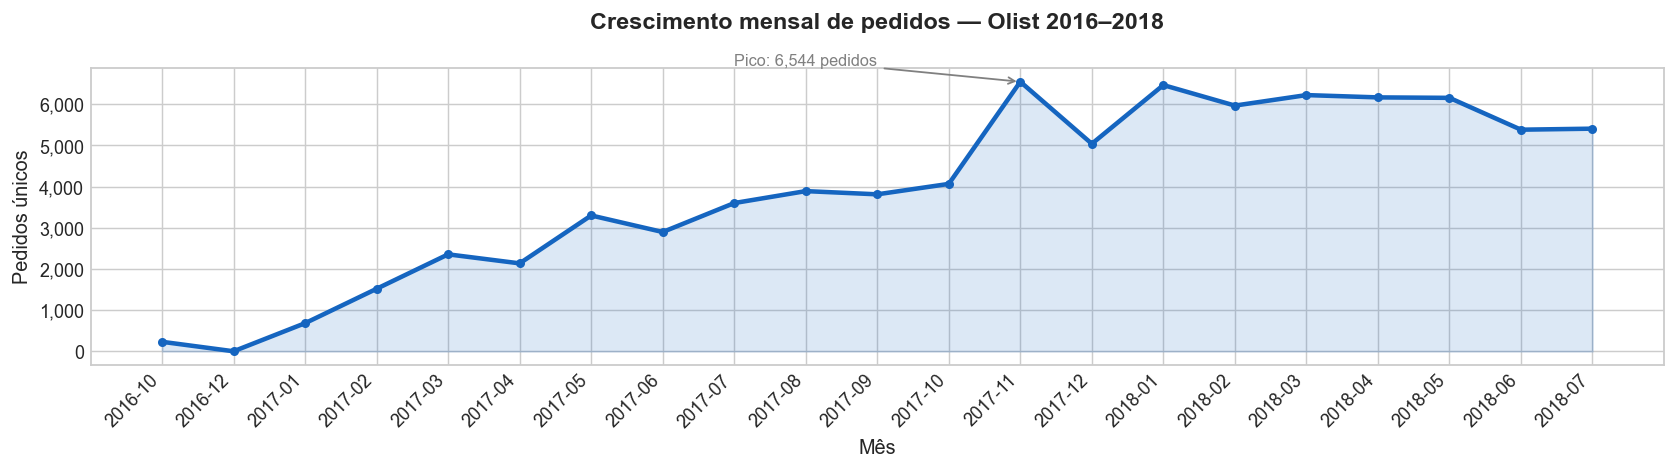

In [15]:
pedidos_mensais = (
    df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['order_id']
    .nunique()
    .reset_index()
)
pedidos_mensais.columns = ['mes', 'pedidos']
pedidos_mensais['mes_str'] = pedidos_mensais['mes'].astype(str)
pedidos_mensais = pedidos_mensais[:-1]

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    pedidos_mensais['mes_str'],
    pedidos_mensais['pedidos'],
    alpha=0.15,
    color=COR_PRINCIPAL
)
ax.plot(
    pedidos_mensais['mes_str'],
    pedidos_mensais['pedidos'],
    color=COR_PRINCIPAL,
    linewidth=2.5,
    marker='o',
    markersize=4
)

idx_max = pedidos_mensais['pedidos'].idxmax()
ax.annotate(
    f"Pico: {pedidos_mensais.loc[idx_max, 'pedidos']:,} pedidos",
    xy=(pedidos_mensais.loc[idx_max, 'mes_str'],
        pedidos_mensais.loc[idx_max, 'pedidos']),
    xytext=(idx_max - 4, pedidos_mensais.loc[idx_max, 'pedidos'] + 400),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9,
    color='gray'
)

ax.set_title('Crescimento mensal de pedidos — Olist 2016–2018', pad=22)
ax.set_xlabel('Mês')
ax.set_ylabel('Pedidos únicos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.93])  # deixa mais espaço no topo
plt.savefig(FIGURES_PATH + '01_pedidos_mensais.png', bbox_inches='tight')
plt.show()

## 2. Impacto do atraso na satisfação

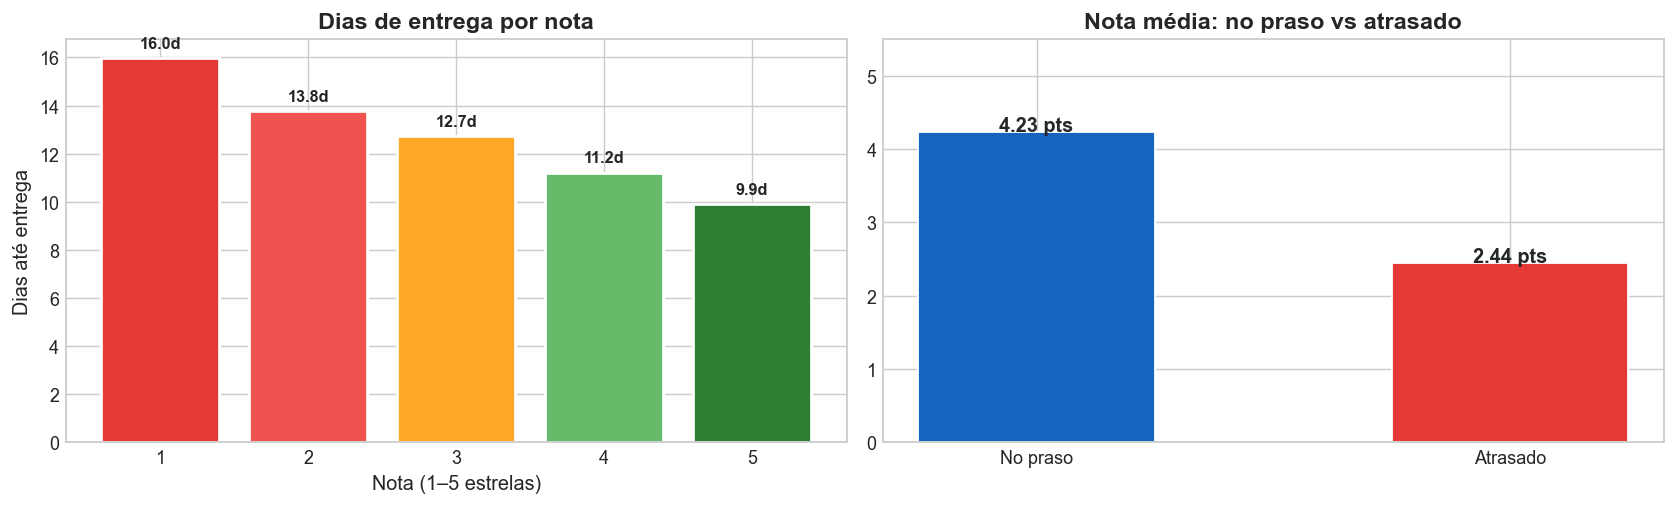

Impacto do atraso: 1.79 pontos a menos na nota


In [16]:
entrega_por_nota = (
    df.groupby('review_score')['delivery_days']
    .mean().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cores = ['#E53935','#EF5350','#FFA726','#66BB6A','#2E7D32']
bars = axes[0].bar(
    entrega_por_nota['review_score'],
    entrega_por_nota['delivery_days'],
    color=cores, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, entrega_por_nota['delivery_days']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}d', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[0].set_title('Dias de entrega por nota')
axes[0].set_xlabel('Nota (1–5 estrelas)')
axes[0].set_ylabel('Dias até entrega')

atrasado = df[df['delay_days'] > 0]['review_score'].mean()
no_prazo = df[df['delay_days'] <= 0]['review_score'].mean()

axes[1].bar(['No praso', 'Atrasado'], [no_prazo, atrasado],
            color=[COR_PRINCIPAL, COR_SECUNDARIA],
            width=0.5, edgecolor='white')
for i, val in enumerate([no_prazo, atrasado]):
    axes[1].text(i, val + 0.02, f'{val:.2f} pts',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Nota média: no praso vs atrasado')
axes[1].set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig(FIGURES_PATH + '02_satisfacao_entrega.png', bbox_inches='tight')
plt.show()

print(f"Impacto do atraso: {no_prazo - atrasado:.2f} pontos a menos na nota")

## 3. Receita por estado

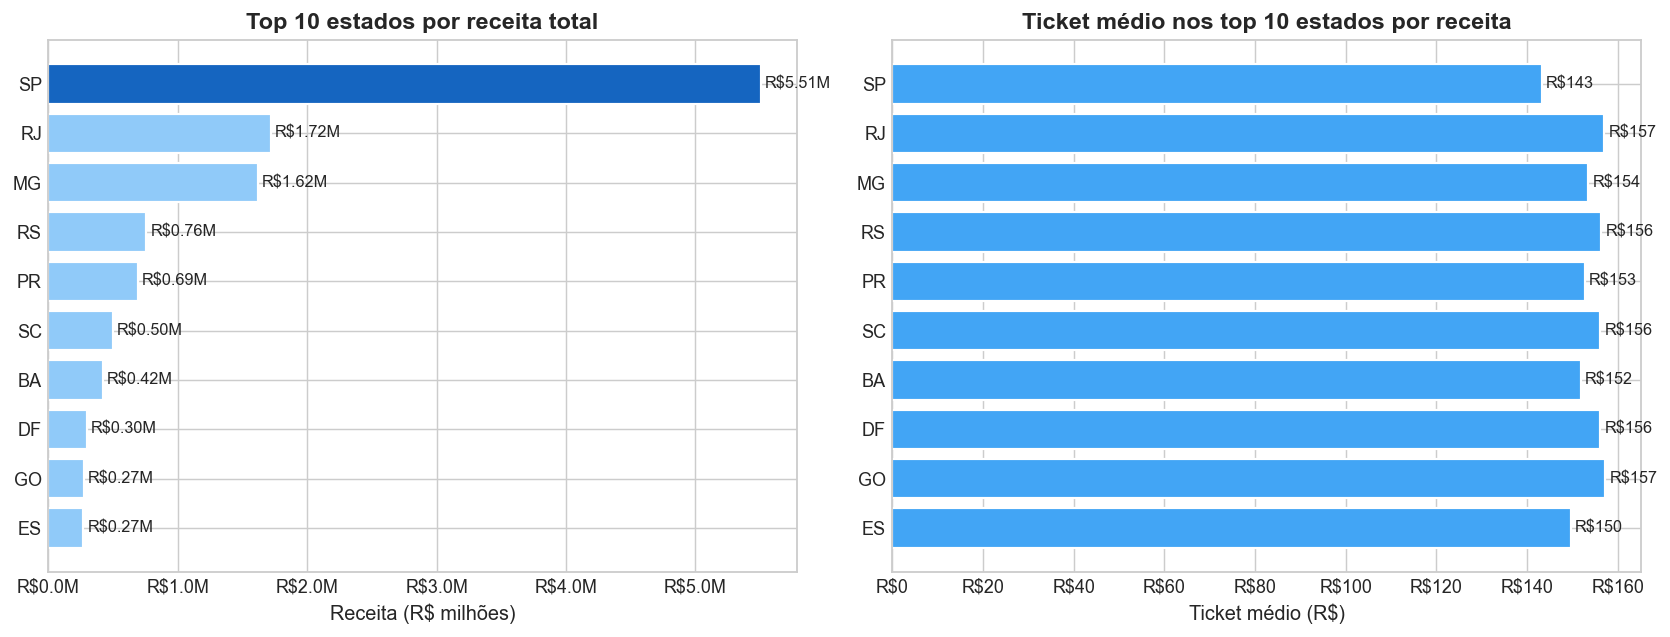

In [17]:
# Consolidar o valor total por pedido em cada estado
ticket_por_pedido = (
    df.groupby(['customer_state', 'order_id'], as_index=False)
    .agg(valor_pedido=('payment_value', 'sum'))
)

# Agregar por estado
receita_estado = (
    ticket_por_pedido.groupby('customer_state', as_index=False)
    .agg(
        receita_total=('valor_pedido', 'sum'),
        ticket_medio=('valor_pedido', 'mean'),
        qtd_pedidos=('valor_pedido', 'size')
    )
    .sort_values('receita_total', ascending=False)
    .head(10)
)

# Inverter para o gráfico horizontal ficar do menor para o maior visualmente
receita_plot = receita_estado.iloc[::-1].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Destacar o estado com maior receita
estado_topo = receita_estado.iloc[0]['customer_state']
cores_barras = [
    COR_PRINCIPAL if estado == estado_topo else '#90CAF9'
    for estado in receita_plot['customer_state']
]

# Gráfico 1
bars1 = axes[0].barh(
    receita_plot['customer_state'],
    receita_plot['receita_total'] / 1e6,
    color=cores_barras,
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_title('Top 10 estados por receita total')
axes[0].set_xlabel('Receita (R$ milhões)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M')
)

for bar, val in zip(bars1, receita_plot['receita_total'] / 1e6):
    axes[0].text(
        val + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'R${val:.2f}M',
        va='center',
        fontsize=9
    )

# Gráfico 2: Ticket médio
bars2 = axes[1].barh(
    receita_plot['customer_state'],
    receita_plot['ticket_medio'],
    color='#42A5F5',
    edgecolor='white',
    linewidth=1.2
)

axes[1].set_title('Ticket médio nos top 10 estados por receita')
axes[1].set_xlabel('Ticket médio (R$)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:.0f}')
)

for bar, val in zip(bars2, receita_plot['ticket_medio']):
    axes[1].text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f'R${val:.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_PATH + '03_receita_por_estado.png', bbox_inches='tight')
plt.show()

## 4. Meios de pagamento

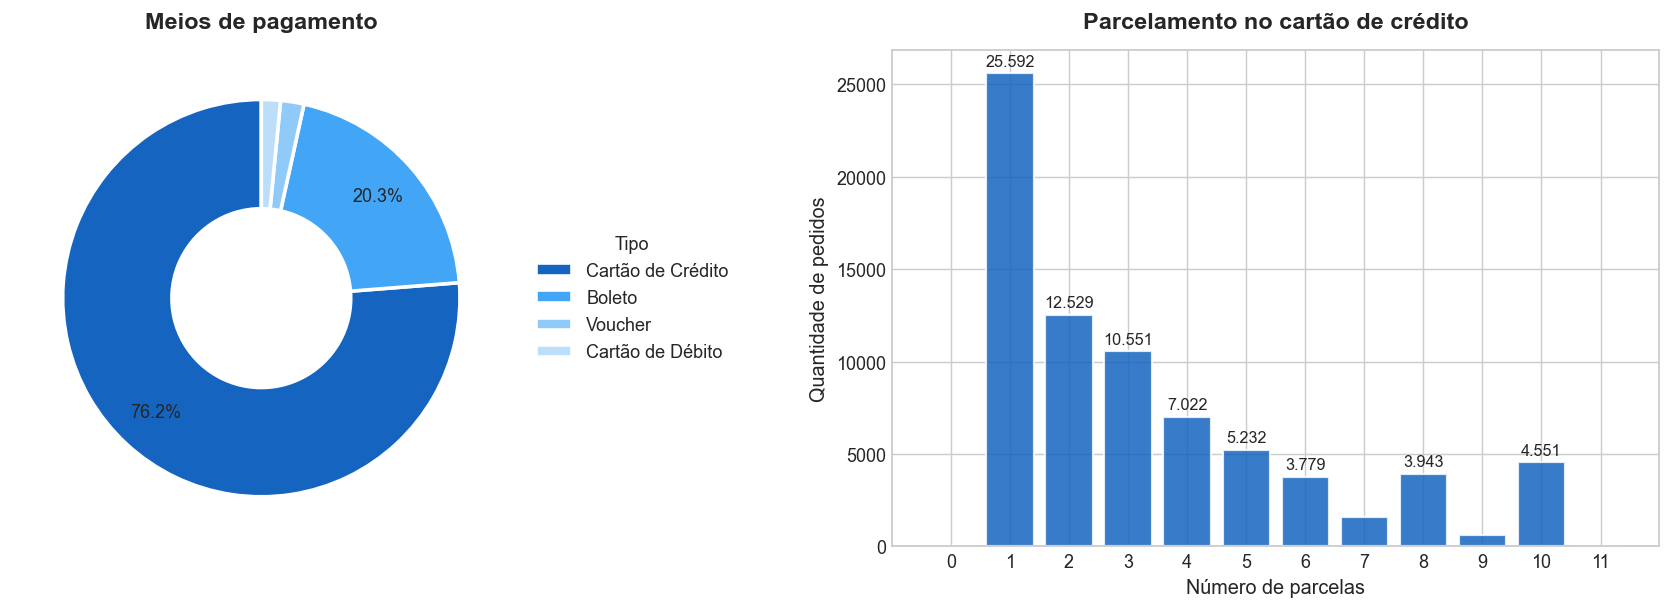

In [18]:
pagamentos = (
    df['payment_type']
    .value_counts()
    .reset_index()
)
pagamentos.columns = ['tipo', 'quantidade']

nomes = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de Débito'
}
pagamentos['tipo_br'] = pagamentos['tipo'].map(nomes).fillna(pagamentos['tipo'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

cores_pagamento = ['#1565C0', '#42A5F5', '#90CAF9', '#BBDEFB'][:len(pagamentos)]

# Mostrar percentual só para fatias maiores
def mostrar_pct(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = axes[0].pie(
    pagamentos['quantidade'],
    labels=None,
    autopct=mostrar_pct,
    colors=cores_pagamento,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    startangle=90,
    pctdistance=0.78
)

axes[0].set_title('Meios de pagamento', pad=12)

axes[0].legend(
    wedges,
    pagamentos['tipo_br'],
    title='Tipo',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Parcelamento no cartão
parcelas = (
    df[df['payment_type'] == 'credit_card']['payment_installments']
    .value_counts()
    .sort_index()
    .head(12)
)

bars = axes[1].bar(
    parcelas.index,
    parcelas.values,
    color=COR_PRINCIPAL,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

axes[1].set_title('Parcelamento no cartão de crédito', pad=12)
axes[1].set_xlabel('Número de parcelas')
axes[1].set_ylabel('Quantidade de pedidos')
axes[1].set_xticks(parcelas.index)

# Opcional: mostrar valor nas barras maiores
for bar, val in zip(bars, parcelas.values):
    if val >= 3000:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 250,
            f'{val:,}'.replace(',', '.'),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig(FIGURES_PATH + '04_pagamentos.png', bbox_inches='tight')
plt.show()

## 5. Matriz de correlação

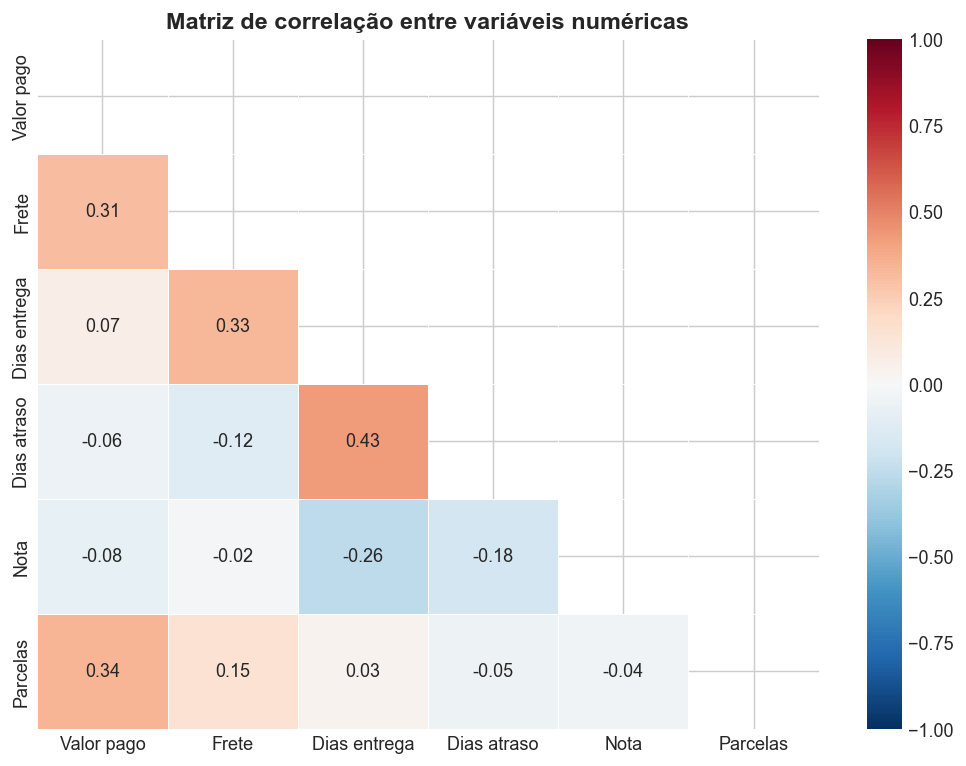

In [19]:
colunas_corr = ['payment_value', 'freight_value', 'delivery_days',
                'delay_days', 'review_score', 'payment_installments']

corr = df[colunas_corr].corr()
nomes_leg = {
    'payment_value': 'Valor pago',
    'freight_value': 'Frete',
    'delivery_days': 'Dias entrega',
    'delay_days': 'Dias atraso',
    'review_score': 'Nota',
    'payment_installments': 'Parcelas'
}
corr.index   = [nomes_leg[c] for c in corr.index]
corr.columns = [nomes_leg[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, vmin=-1, vmax=1)
ax.set_title('Matriz de correlação entre variáveis numéricas')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '05_correlacao.png', bbox_inches='tight')
plt.show()

## Resumo dos insights

In [20]:
atrasado      = df[df['delay_days'] > 0]['review_score'].mean()
no_prazo      = df[df['delay_days'] <= 0]['review_score'].mean()
pct_atrasados = (df['delay_days'] > 0).sum() / len(df) * 100
sp_share      = (df[df['customer_state'] == 'SP']['payment_value'].sum()
                 / df['payment_value'].sum() * 100)
cc_pct        = (df['payment_type'] == 'credit_card').sum() / len(df) * 100

print("=" * 55)
print("  INSIGHTS — OLIST E-COMMERCE EDA")
print("=" * 55)
print(f"\n CRESCIMENTO")
print(f"   +300% nos pedidos ao longo de 2017")
print(f"\n SATISFAÇÃO")
print(f"   Atraso reduz a nota em {no_prazo - atrasado:.1f} pontos")
print(f"   ({pct_atrasados:.1f}% dos pedidos entregues com atraso)")
print(f"\n GEOGRAFIA")
print(f"   SP concentra {sp_share:.1f}% da receita total")
print(f"\n PAGAMENTO")
print(f"   {cc_pct:.1f}% pagam com cartão de crédito")
print("\n" + "=" * 55)
print("  Gráficos salvos em reports/figures/")
print("=" * 55)

  INSIGHTS — OLIST E-COMMERCE EDA

 CRESCIMENTO
   +300% nos pedidos ao longo de 2017

 SATISFAÇÃO
   Atraso reduz a nota em 1.8 pontos
   (5.3% dos pedidos entregues com atraso)

 GEOGRAFIA
   SP concentra 41.8% da receita total

 PAGAMENTO
   76.2% pagam com cartão de crédito

  Gráficos salvos em reports/figures/
